# OCR Reflow with Layout Analysis

This notebook demonstrates how to use the OCR reflow package with layout analysis to process book pages.

## Overview

The layout analysis detects different content types:
- **Plain text** and **titles**: Reflowed with proper line wrapping
- **Figures** and **figure captions**: Grouped and placed as-is (zoomed)
- **Tables** and **table captions/footnotes**: Placed as-is (zoomed)
- **Formulas** and **formula captions**: Grouped and placed as-is (zoomed)
- **Abandon**: Headers/footers (ignored)

## Setup

In [1]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src directory to path
project_root = Path.cwd().parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Import ocr_reflow functions
from ocr_reflow.main import process_document_with_layout
from ocr_reflow.layout import layout as analyze_layout

print("✓ Imports successful")

✓ Imports successful


## Configure Input Image

In [2]:
# Set your input image path here
input_image = project_root / "images" / "dvurog_p021.png"

# Alternative images to try:
# input_image = project_root / "images" / "kf_p015.png"
# input_image = Path("out13.png")  # Use a notebook image

if not input_image.exists():
    print(f"❌ Image not found: {input_image}")
else:
    print(f"✓ Using image: {input_image}")

✓ Using image: /home/sergey/code/python/segmentation/images/dvurog_p021.png


## Step 1: View Original Image

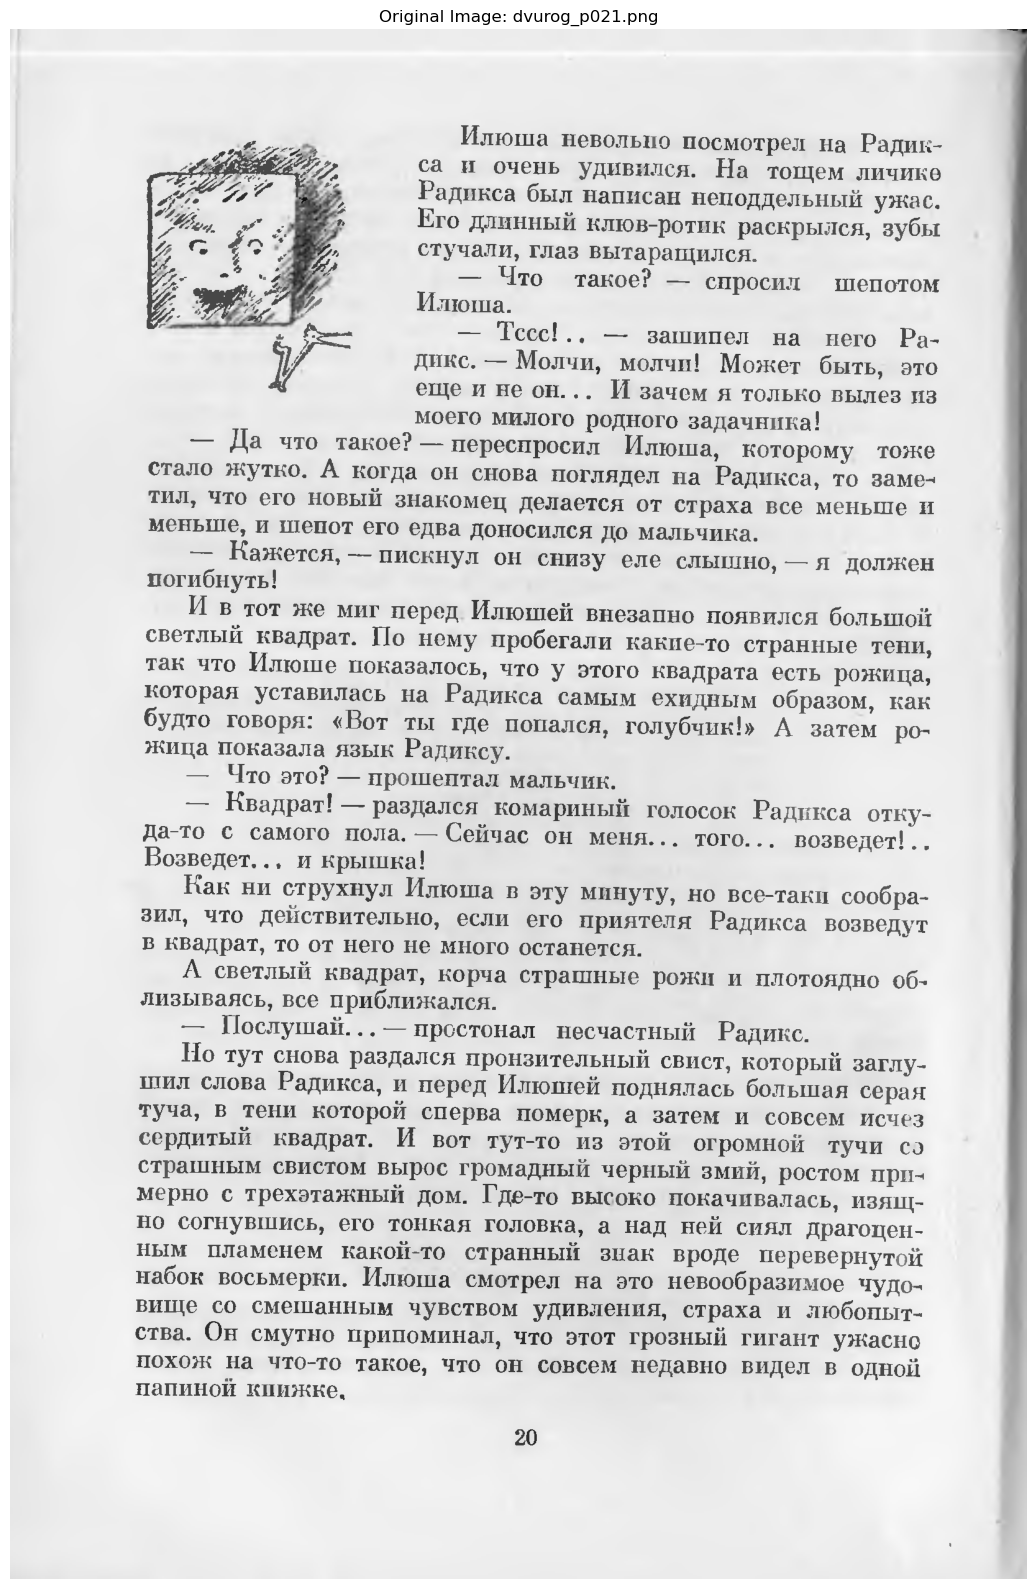

Image size: 1637 x 2495 pixels


In [3]:
# Load and display the original image
img = cv2.imread(str(input_image))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 16))
plt.imshow(img_rgb)
plt.title(f"Original Image: {input_image.name}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image size: {img.shape[1]} x {img.shape[0]} pixels")

## Step 2: Run Layout Analysis

Detect different content types in the image.

In [4]:
print("Running layout analysis...")
layout_boxes = analyze_layout(str(input_image))

# Sort boxes by y position (top to bottom), then x position (left to right)
layout_boxes_sorted = sorted(layout_boxes, key=lambda item: (item[0].bounds[1], item[0].bounds[0]))

print(f"\n✓ Detected {len(layout_boxes_sorted)} layout boxes:\n")
for i, (box_geom, box_type) in enumerate(layout_boxes_sorted, 1):
    bounds = box_geom.bounds
    print(f"{i:2d}. {box_type:20s}: ({bounds[0]:6.1f}, {bounds[1]:6.1f}) -> ({bounds[2]:6.1f}, {bounds[3]:6.1f})")

Running layout analysis...

image 1/1 /home/sergey/code/python/segmentation/images/dvurog_p021.png: 1024x672 12 plain texts, 1 abandon, 1 figure, 1059.8ms
Speed: 3.2ms preprocess, 1059.8ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 672)

✓ Detected 13 layout boxes:

 1. plain text          : ( 652.3,  151.7) -> (1504.5,  379.3)
 2. figure              : ( 211.1,  169.2) -> ( 559.0,  592.6)
 3. plain text          : ( 651.8,  381.6) -> (1500.4,  465.0)
 4. plain text          : ( 218.1,  470.2) -> (1499.6,  828.9)
 5. plain text          : ( 218.0,  831.5) -> (1491.9,  911.8)
 6. plain text          : ( 213.6,  915.4) -> (1490.7, 1184.4)
 7. plain text          : ( 279.1, 1185.3) -> ( 979.8, 1227.6)
 8. plain text          : ( 209.2, 1232.4) -> (1485.7, 1361.6)
 9. plain text          : ( 207.0, 1367.2) -> (1483.2, 1498.4)
10. plain text          : ( 208.0, 1503.1) -> (1481.7, 1586.0)
11. plain text          : ( 267.3, 1590.4) -> (1292.5, 1633.8)
12. plain text        

## Step 3: Visualize Layout Detection

Show detected boxes overlaid on the original image.

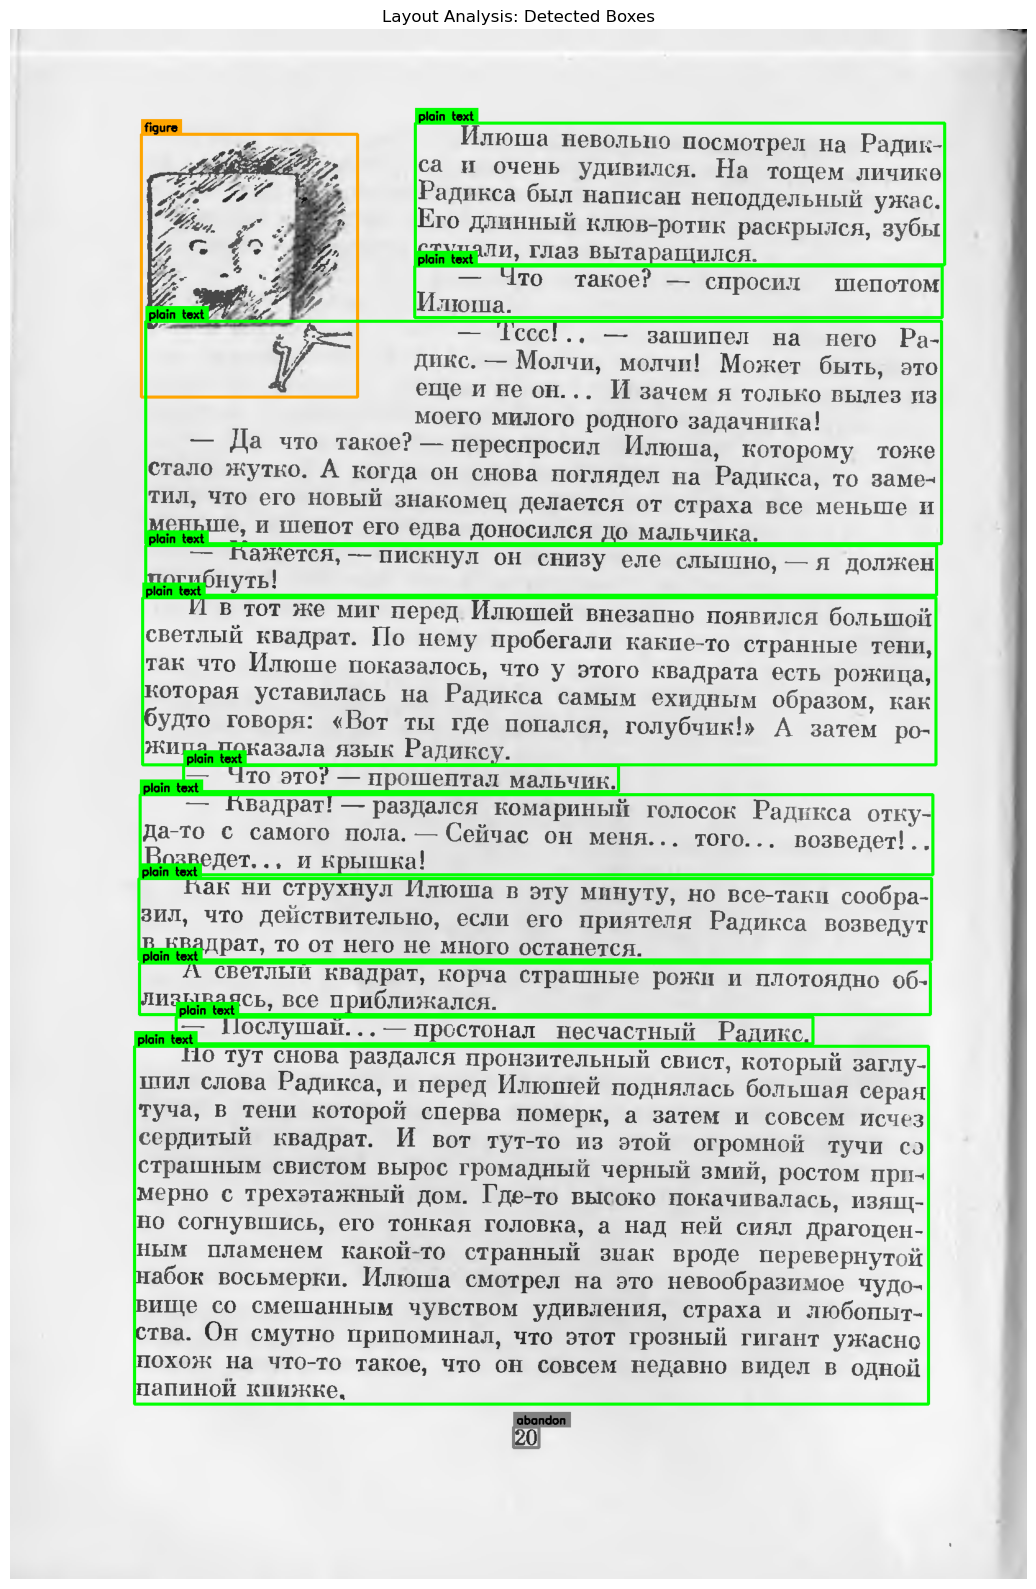


Color Legend:
  plain text                    : RGB(0, 255, 0)
  abandon                       : RGB(128, 128, 128)
  figure                        : RGB(255, 165, 0)


In [5]:
# Create a copy of the image for visualization
img_with_boxes = img_rgb.copy()

# Define colors for different box types
type_colors = {
    'title': (255, 0, 0),              # Red
    'plain text': (0, 255, 0),         # Green
    'abandon': (128, 128, 128),        # Gray
    'figure': (255, 165, 0),           # Orange
    'figure_caption': (255, 200, 0),   # Light Orange
    'figure_and_caption': (255, 140, 0), # Dark Orange
    'table': (0, 255, 255),            # Cyan
    'table_caption': (0, 200, 255),    # Light Cyan
    'table_footnote': (0, 150, 255),   # Medium Cyan
    'isolate_formula': (255, 0, 255),  # Magenta
    'formula_caption': (200, 0, 255),  # Light Magenta
    'isolate_formula_and_caption': (180, 0, 255),  # Medium Magenta
}

# Draw boxes
for box_geom, box_type in layout_boxes_sorted:
    bounds = box_geom.bounds
    xmin, ymin, xmax, ymax = int(bounds[0]), int(bounds[1]), int(bounds[2]), int(bounds[3])
    
    color = type_colors.get(box_type, (255, 255, 255))
    
    # Draw rectangle
    cv2.rectangle(img_with_boxes, (xmin, ymin), (xmax, ymax), color, 3)
    
    # Add label
    label = box_type
    label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
    cv2.rectangle(img_with_boxes, 
                  (xmin, ymin - label_size[1] - 10), 
                  (xmin + label_size[0] + 10, ymin), 
                  color, -1)
    cv2.putText(img_with_boxes, label, (xmin + 5, ymin - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

plt.figure(figsize=(12, 16))
plt.imshow(img_with_boxes)
plt.title("Layout Analysis: Detected Boxes")
plt.axis('off')
plt.tight_layout()
plt.show()

# Show legend
print("\nColor Legend:")
for box_type, color in type_colors.items():
    if any(bt == box_type for _, bt in layout_boxes_sorted):
        print(f"  {box_type:30s}: RGB{color}")

## Step 4: Run Reflow with Layout Analysis

Process the document and create a reflowed page.

In [6]:
# Configure reflow parameters
zoom_factor = 2.5       # Scaling factor for non-text content (figures, formulas, etc.)
new_page_width = 2000   # Width of the new page in pixels

print(f"Running reflow with layout analysis...")
print(f"  Zoom factor: {zoom_factor}")
print(f"  New page width: {new_page_width}px\n")

reflowed_page = process_document_with_layout(
    str(input_image), 
    zoom_factor=zoom_factor, 
    new_page_width=new_page_width
)

print(f"\n✓ Reflow complete!")
print(f"  Output size: {reflowed_page.shape[1]} x {reflowed_page.shape[0]} pixels")

Running reflow with layout analysis...
  Zoom factor: 2.5
  New page width: 2000px

Detected background color (BGR): [232 232 232]
Running layout analysis...

image 1/1 /home/sergey/code/python/segmentation/images/dvurog_p021.png: 1024x672 12 plain texts, 1 abandon, 1 figure, 1009.3ms
Speed: 3.7ms preprocess, 1009.3ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 672)
Detected 13 layout boxes:
  plain text: (652.3, 151.7, 1504.5, 379.3)
  figure: (211.1, 169.2, 559.0, 592.6)
  plain text: (651.8, 381.6, 1500.4, 465.0)
  plain text: (218.1, 470.2, 1499.6, 828.9)
  plain text: (218.0, 831.5, 1491.9, 911.8)
  plain text: (213.6, 915.4, 1490.7, 1184.4)
  plain text: (279.1, 1185.3, 979.8, 1227.6)
  plain text: (209.2, 1232.4, 1485.7, 1361.6)
  plain text: (207.0, 1367.2, 1483.2, 1498.4)
  plain text: (208.0, 1503.1, 1481.7, 1586.0)
  plain text: (267.3, 1590.4, 1292.5, 1633.8)
  plain text: (200.8, 1637.7, 1478.7, 2213.4)
  abandon: (810.0, 2250.8, 851.1, 2283.5)

Processing

## Step 5: Display Reflowed Result

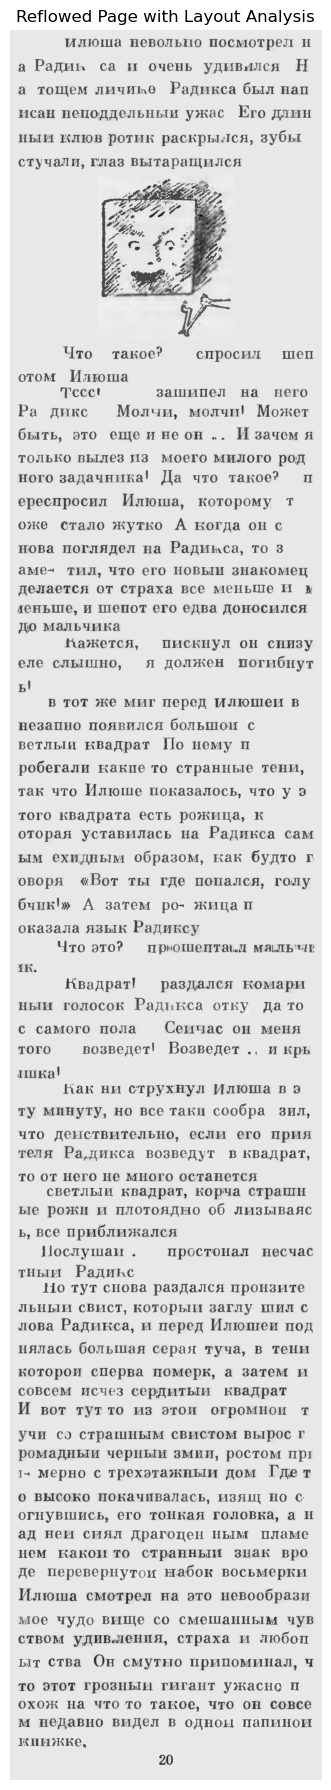

In [7]:
# Convert to RGB for display
reflowed_rgb = cv2.cvtColor(reflowed_page, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 18))
plt.imshow(reflowed_rgb)
plt.title("Reflowed Page with Layout Analysis")
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 6: Side-by-Side Comparison

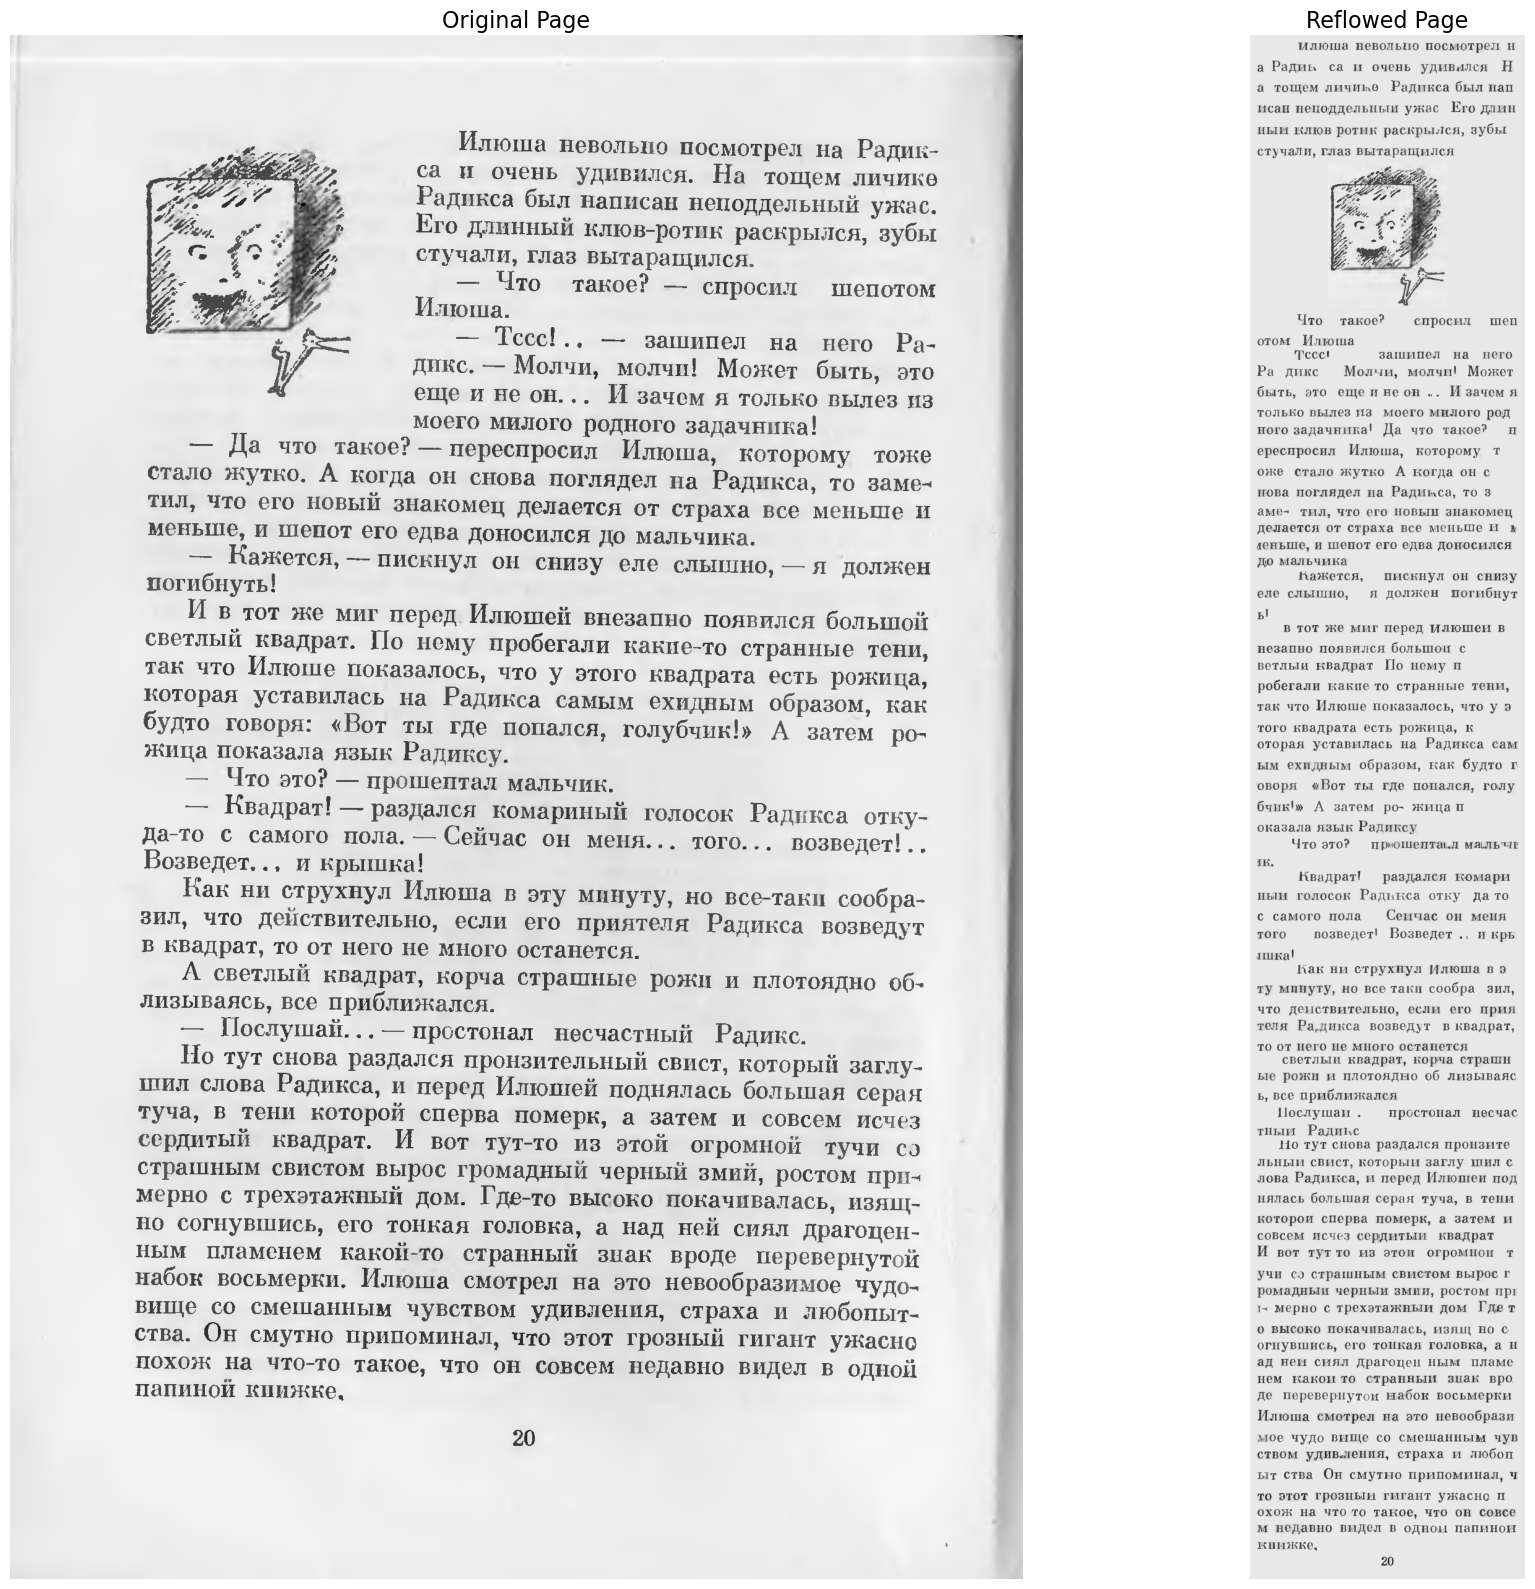

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 16))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Page", fontsize=16)
axes[0].axis('off')

axes[1].imshow(reflowed_rgb)
axes[1].set_title("Reflowed Page", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 7: Save Output

In [9]:
# Save the reflowed image
output_filename = f"reflowed_{input_image.stem}.png"
output_path = Path.cwd() / output_filename

cv2.imwrite(str(output_path), reflowed_page)
print(f"✓ Saved reflowed image to: {output_path}")

# Also save the layout visualization
layout_viz_filename = f"layout_viz_{input_image.stem}.png"
layout_viz_path = Path.cwd() / layout_viz_filename

img_with_boxes_bgr = cv2.cvtColor(img_with_boxes, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(layout_viz_path), img_with_boxes_bgr)
print(f"✓ Saved layout visualization to: {layout_viz_path}")

✓ Saved reflowed image to: /home/sergey/code/python/segmentation/notebooks/reflowed_dvurog_p021.png
✓ Saved layout visualization to: /home/sergey/code/python/segmentation/notebooks/layout_viz_dvurog_p021.png


## Step 8: Inspect Specific Region (Optional)

Zoom into a specific area of the reflowed page to check quality.

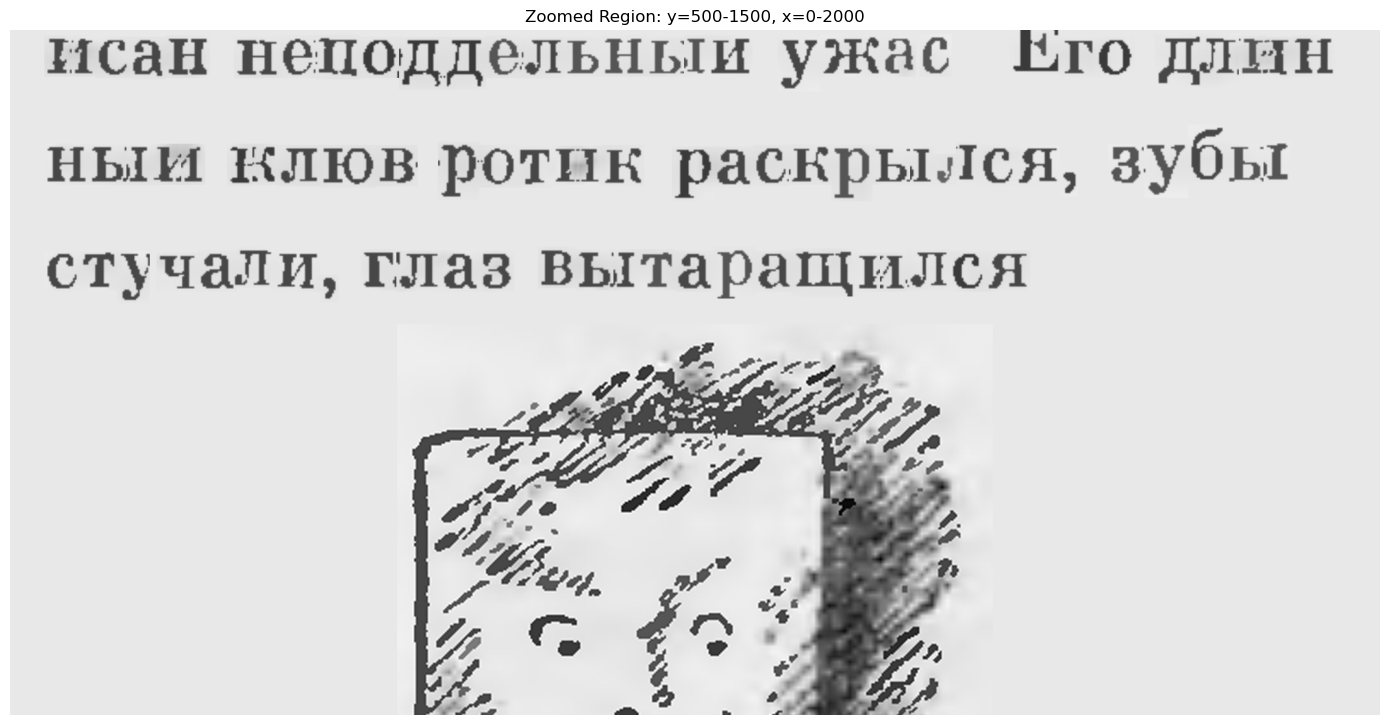

In [10]:
# Define region to inspect (y_start, y_end, x_start, x_end)
# Adjust these values to inspect different regions
y_start, y_end = 500, 1500
x_start, x_end = 0, 2000

# Ensure bounds are valid
y_end = min(y_end, reflowed_page.shape[0])
x_end = min(x_end, reflowed_page.shape[1])

region = reflowed_rgb[y_start:y_end, x_start:x_end]

plt.figure(figsize=(14, 10))
plt.imshow(region)
plt.title(f"Zoomed Region: y={y_start}-{y_end}, x={x_start}-{x_end}")
plt.axis('off')
plt.tight_layout()
plt.show()

## Experiment with Different Parameters

You can modify parameters and re-run the reflow:

Testing zoom_factor=2.0...
Detected background color (BGR): [232 232 232]
Running layout analysis...

image 1/1 /home/sergey/code/python/segmentation/images/dvurog_p021.png: 1024x672 12 plain texts, 1 abandon, 1 figure, 826.6ms
Speed: 3.3ms preprocess, 826.6ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 672)
Detected 13 layout boxes:
  plain text: (652.3, 151.7, 1504.5, 379.3)
  figure: (211.1, 169.2, 559.0, 592.6)
  plain text: (651.8, 381.6, 1500.4, 465.0)
  plain text: (218.1, 470.2, 1499.6, 828.9)
  plain text: (218.0, 831.5, 1491.9, 911.8)
  plain text: (213.6, 915.4, 1490.7, 1184.4)
  plain text: (279.1, 1185.3, 979.8, 1227.6)
  plain text: (209.2, 1232.4, 1485.7, 1361.6)
  plain text: (207.0, 1367.2, 1483.2, 1498.4)
  plain text: (208.0, 1503.1, 1481.7, 1586.0)
  plain text: (267.3, 1590.4, 1292.5, 1633.8)
  plain text: (200.8, 1637.7, 1478.7, 2213.4)
  abandon: (810.0, 2250.8, 851.1, 2283.5)

Processing plain text box at y=151
Detected 1 paragraphs
Paragraph st

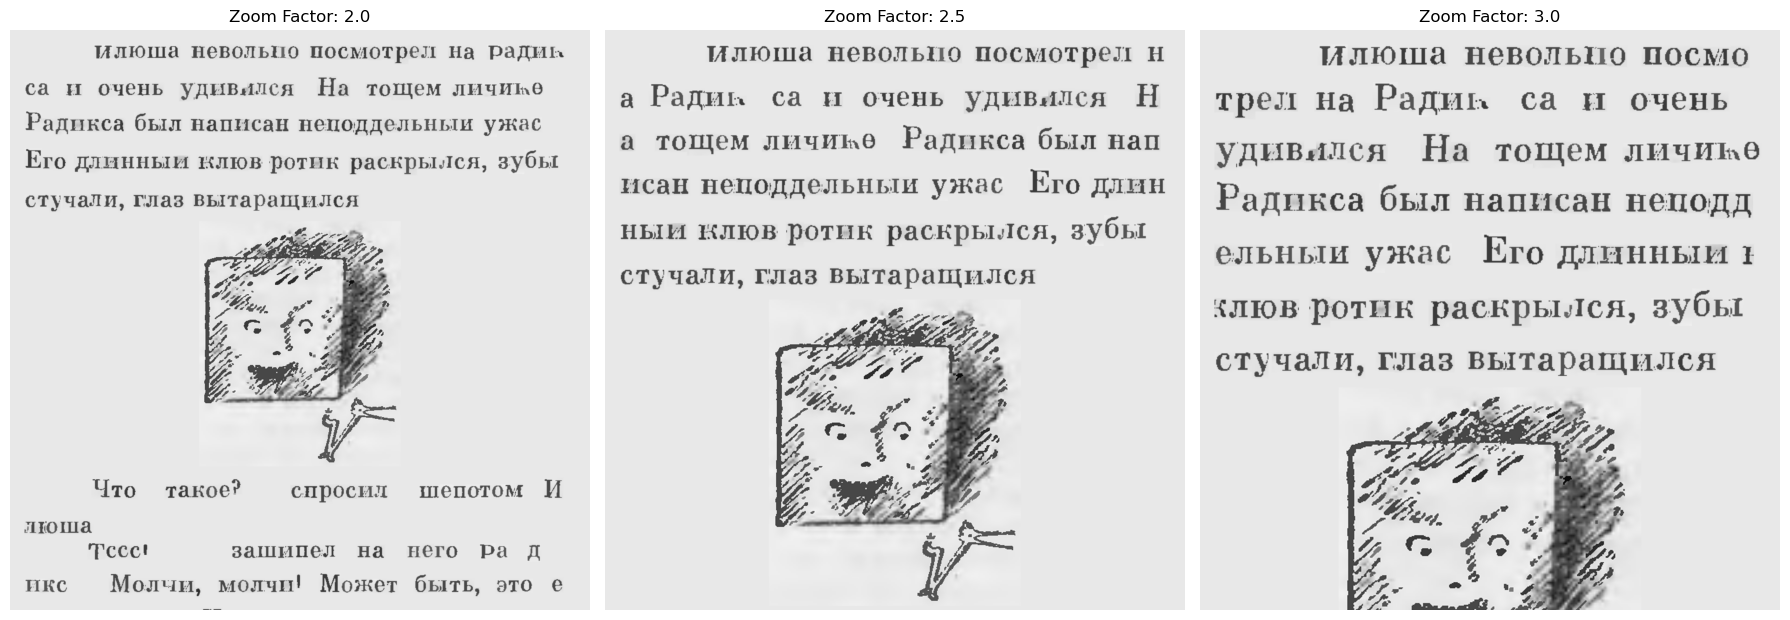

In [11]:
# Try different zoom factors
zoom_factors = [2.0, 2.5, 3.0]

fig, axes = plt.subplots(1, len(zoom_factors), figsize=(18, 12))

for i, zoom in enumerate(zoom_factors):
    print(f"Testing zoom_factor={zoom}...")
    reflowed = process_document_with_layout(
        str(input_image), 
        zoom_factor=zoom, 
        new_page_width=2000
    )
    reflowed_rgb_test = cv2.cvtColor(reflowed, cv2.COLOR_BGR2RGB)
    
    # Show only top portion for comparison
    axes[i].imshow(reflowed_rgb_test[:2000, :])
    axes[i].set_title(f"Zoom Factor: {zoom}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Summary Statistics

In [12]:
# Count box types
from collections import Counter

type_counts = Counter(box_type for _, box_type in layout_boxes_sorted)

print("\nLayout Box Type Distribution:")
print("=" * 40)
for box_type, count in sorted(type_counts.items()):
    print(f"{box_type:30s}: {count:2d}")
print("=" * 40)
print(f"{'Total':30s}: {len(layout_boxes_sorted):2d}")

# Image size comparison
print(f"\nImage Size Comparison:")
print("=" * 40)
print(f"Original: {img.shape[1]:4d} x {img.shape[0]:4d} px")
print(f"Reflowed: {reflowed_page.shape[1]:4d} x {reflowed_page.shape[0]:4d} px")
print(f"Height change: {reflowed_page.shape[0] / img.shape[0]:.2f}x")


Layout Box Type Distribution:
abandon                       :  1
figure                        :  1
plain text                    : 11
Total                         : 13

Image Size Comparison:
Original: 1637 x 2495 px
Reflowed: 2000 x 11233 px
Height change: 4.50x
